In [3]:
# uv add langchain-community pdfplumber
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader("../data/Employee_Benefits_Guide_2026_v1.pdf")
documents = loader.load()

In [5]:
# uv add langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=100)
texts = text_splitter.split_documents(documents)

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

store = LocalFileStore("./cache/")

cached_embedder = CacheBackedEmbeddings.from_bytes_store(
    embeddings,
    store,
    namespace=embeddings.model
)

d:\wsh\langchain-workspace\ch14\.venv\Lib\site-packages\langchain_classic\embeddings\cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [10]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(texts, cached_embedder) # in-memory

In [14]:
vector_store.save_local("faiss_index")

In [18]:
vector_store = None

In [20]:
vector_store = FAISS.load_local(
    "faiss_index",
    cached_embedder,
    allow_dangerous_deserialization=True
)

In [21]:
vector_store

In [37]:
retriever = vector_store.as_retriever()

In [38]:
retriever.invoke("결혼식을 하게되면 얼마를 받을 수 있을까?")

[Document(id='6b1634ad-4f5a-4be3-a8b5-fdb7f5d33f64', metadata={'source': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'page': 11, 'total_pages': 22, 'Author': '', 'CreationDate': "D:20260116002528+09'00'", 'ModDate': "D:20260116002528+09'00'", 'Producer': 'Microsoft: Print To PDF', 'Title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx'}, page_content='\uf0b7 소멸: 당해 연도 12 월 31 일까지 미사용 시 자동 소멸 (이월 불가).\n5.4 경조사 지원 기준 (Family Support Details)\n기쁨과 슬픔을 함께 나누는 테크노빌드의 경조 지원입니다.\n구분 대상 휴가 (일수) 경조금 (만원) 화환/조화\n결혼 본인 5 일 100 + 화환 지원\n자녀 1 일 50 + 화환 지원\n30 -\n형제/자매 1 일\n30 -\n회갑/칠순 본인/배우자 부모 1 일\n출산 본인 출산휴가 (90 일) 출산 축하금 50 과일 바구니\n배우자 10 일 (유급) 출산 축하금 50 과일 바구니\n-\n사망 본인/배우자 500 + 장례용품 3 단 조화 + 근조기\n부모/배우자 부모 5 일 100 + 장례용품 3 단 조화 + 근조기\n30\n조부모/외조부모 3 일 조화\n30\n형제/자매 3 일 조화'),
 Document(id='db46d813-1a1f-4f0f-aa19-98ca0ca98130', metadata={'source': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '../data/Employ

In [39]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [40]:
from typing import TypedDict, List
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [41]:
def retrieve(state: AgentState) -> AgentState:
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [28]:
# Create a LangSmith API in Settings > API Keys
# Make sure API key env var is set:
# import os; os.environ["LANGSMITH_API_KEY"] = "<your-api-key>"
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

In [43]:
def generate(state: AgentState) -> AgentState:
    context = state["context"]
    query = state["query"]
    rag_chain = prompt | model
    response = rag_chain.invoke({"question": query, "context": context})
    return {'answer': response}

In [44]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

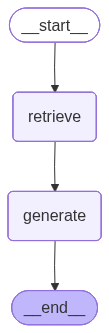

In [45]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
result = graph.invoke({'query': '결혼을 하게 되었어. 얼마를 받을 수 있을까?'})

In [47]:
result

{'query': '결혼을 하게 되었어. 얼마를 받을 수 있을까?',
 'context': [Document(id='0c0bdb3b-7875-4db5-9acf-8710337ec24b', metadata={'source': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'page': 21, 'total_pages': 22, 'Author': '', 'CreationDate': "D:20260116002528+09'00'", 'ModDate': "D:20260116002528+09'00'", 'Producer': 'Microsoft: Print To PDF', 'Title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx'}, page_content='300 만원 + 웰니스 포인트 200 만P + 부부 동반 정밀 검진권.\n[시나리오 2: 중기 근속자] - 대상: 2020 년 7 월 1 일 입사한 T3 직급 직원 - 현재 시점:\n2026 년 1 월 1 일 (근속 약 5.5 년) - 발생 혜택: 1. 기본 연차 15 일 + 가산 연차 2 일 (3,\n5 주년 가산) = 총 17 일 발생. 2. 5 주년 리프레시 휴가 10 일 (만 5 년 시점인 2025.07 에\n이미 발생했으나 미사용분 이월 가능 여부 확인 필요). 3. 휴가비 100 만원 + 웰니스 포인트\n120 만P.\n[문서 끝] 본 가이드북의 내용은 대한민국 근로기준법 및 관련 법령, 회사 취업규칙의\n변경에 따라 매년 갱신될 수 있습니다.'),
  Document(id='6b1634ad-4f5a-4be3-a8b5-fdb7f5d33f64', metadata={'source': '../data/Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '../data/Employ